# UT2 · Sistemas de Aprendizaje Automático + Python — Cuaderno práctico

Este cuaderno acompaña a la parte práctica de la Unidad 2. Recorre NumPy, Pandas (carga, exploración y limpieza), Matplotlib básico, y cierra con un primer vistazo a Scikit-learn.

No hace falta ningún archivo externo: el dataset de ejemplo se genera dentro del propio cuaderno, así que puedes ejecutar todas las celdas de arriba a abajo sin preparación previa.

**Cómo usarlo en clase:** cada bloque tiene primero una celda de práctica guiada (ya resuelta, para seguir el razonamiento) y después, en varios bloques, un mini-reto para que el alumnado lo intente antes de mirar la celda siguiente.

In [1]:
# Si alguna librería falta, descomenta e instala:
# !pip install numpy pandas matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1 · NumPy: de listas a arrays

Empezamos por la base: crear arrays, indexarlos y comparar cómo cambian las operaciones respecto a una lista de Python normal.

In [2]:
precios_lista = [10, 20, 30]
precios_array = np.array(precios_lista)

print("Lista   * 2:", precios_lista * 2)   # repite la secuencia
print("Array   * 2:", precios_array * 2)   # multiplica cada elemento

Lista   * 2: [10, 20, 30, 10, 20, 30]
Array   * 2: [20 40 60]


In [3]:
# Matriz 2D y las tres formas de indexar más usadas
m = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])

print("Primera fila:      ", m[0])
print("Segunda columna:    ", m[:, 1])
print("Elementos > 5:      ", m[m > 5])
print("Forma de la matriz: ", m.shape)

Primera fila:       [1 2 3]
Segunda columna:     [2 5 8]
Elementos > 5:       [6 7 8 9]
Forma de la matriz:  (3, 3)


In [4]:
puntuaciones = np.array([3, 7, 5, 9, 2, 6, 8, 4, 10, 1])

print("Media:            ", puntuaciones.mean())
print("Desviación típica:", round(puntuaciones.std(), 2))
print("Máximo / mínimo:  ", puntuaciones.max(), "/", puntuaciones.min())

altas_mask = puntuaciones >= 5
print("¿Puntuación alta? ", altas_mask)
print("Puntuaciones altas:", puntuaciones[altas_mask])


Media:             5.5
Desviación típica: 2.87
Máximo / mínimo:   10 / 1
¿Puntuación alta?  [False  True  True  True False  True  True False  True False]
Puntuaciones altas: [ 7  5  9  6  8 10]


### Funciones para crear arrays

No siempre partimos de una lista: muchas veces necesitamos crear un array "desde cero" con una forma concreta.

In [5]:
# Formas habituales de crear arrays sin escribir los valores a mano
ceros = np.zeros((2, 3))
unos = np.ones((2, 3))
llenos = np.full((2, 3), 7)
identidad = np.eye(3)
secuencia = np.arange(0, 10, 2)          # de 0 a 10 (sin incluir), de 2 en 2
espaciado = np.linspace(0, 1, 5)          # 5 valores igualmente repartidos entre 0 y 1

print("zeros:\n", ceros)
print("full:\n", llenos)
print("eye:\n", identidad)
print("arange:", secuencia)
print("linspace:", espaciado)


zeros:
 [[0. 0. 0.]
 [0. 0. 0.]]
full:
 [[7 7 7]
 [7 7 7]]
eye:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
arange: [0 2 4 6 8]
linspace: [0.   0.25 0.5  0.75 1.  ]


### Inspeccionar, reorganizar y combinar arrays

In [6]:
print("shape:", m.shape, " ndim:", m.ndim, " size:", m.size, " dtype:", m.dtype)

# reshape cambia la forma sin cambiar los datos
plano = m.reshape(9)
print("reshape a 1D:", plano)
print("traspuesta:\n", m.T)

# combinar arrays
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print("concatenate:", np.concatenate([a, b]))
print("vstack:\n", np.vstack([a, b]))
print("hstack:", np.hstack([a, b]))


shape: (3, 3)  ndim: 2  size: 9  dtype: int64
reshape a 1D: [1 2 3 4 5 6 7 8 9]
traspuesta:
 [[1 4 7]
 [2 5 8]
 [3 6 9]]
concatenate: [1 2 3 4 5 6]
vstack:
 [[1 2 3]
 [4 5 6]]
hstack: [1 2 3 4 5 6]


**Reto rápido:** crea un array `temperaturas` con 7 valores (uno por día de la semana) y calcula cuántos días ha hecho más de 25°. Pista: usa una máscara booleana y `.sum()` (True cuenta como 1).

In [7]:
# Solución del reto
temperaturas = np.array([22, 26, 31, 19, 28, 33, 24])
dias_calurosos = (temperaturas > 25).sum()
print(f"Días con más de 25°: {dias_calurosos}")

Días con más de 25°: 4


## 2 · Pandas: creamos un dataset de ejemplo

En clase normalmente cargaréis un CSV con `pd.read_csv("archivo.csv")`. Aquí generamos uno en memoria — estadísticas de jugadores de un videojuego online, con nulos y duplicados incluidos a propósito — para poder practicar limpieza sin depender de ningún archivo externo.

In [8]:
plataformas = ["PC", "Consola"]
n = 40

df = pd.DataFrame({
    "jugador_id": range(1, n + 1),
    "plataforma": np.random.choice(plataformas, size=n),
    "horas_jugadas": np.round(np.random.normal(6, 2, size=n), 1),
    "puntuacion": np.round(np.random.normal(6.2, 1.8, size=n), 1),
})

# Ensuciamos el dataset a propósito, como pasa con datos reales
df.loc[[3, 15, 27], "puntuacion"] = np.nan          # algunos nulos
df.loc[[5, 22], "horas_jugadas"] = np.nan
df = pd.concat([df, df.iloc[[0, 1]]], ignore_index=True)  # dos filas duplicadas
df["puntuacion"] = df["puntuacion"].clip(0, 10)

df.head()


,jugador_id,plataforma,horas_jugadas,puntuacion
0,1,PC,4.0,4.7
1,2,Consola,6.6,5.6
2,3,PC,4.2,6.8
3,4,PC,3.2,NaN
4,5,PC,8.9,5.3


### Exploración inicial

Antes de tocar nada, siempre lo mismo: cuántas filas y columnas hay, de qué tipo es cada una, y si hay huecos.

In [9]:
print("Forma del dataset (filas, columnas):", df.shape)
df.info()

Forma del dataset (filas, columnas): (42, 4)
<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   jugador_id     42 non-null     int64  
 1   plataforma     42 non-null     str    
 2   horas_jugadas  40 non-null     float64
 3   puntuacion     39 non-null     float64
dtypes: float64(2), int64(1), str(1)
memory usage: 1.4 KB


In [10]:
df.describe()

,jugador_id,horas_jugadas,puntuacion
count,42.000000,40.000000,39.000000
mean,19.595238,5.592500,5.992308
std,12.115420,1.796491,1.627298
min,1.000000,2.100000,1.500000
25%,9.250000,4.150000,5.100000
50%,19.500000,5.600000,5.900000
75%,29.750000,6.625000,6.900000
max,40.000000,9.700000,9.000000


In [11]:
# Filtrado con máscaras booleanas
alta_habilidad = df[df["puntuacion"] >= 7]
pc_alta_habilidad = df[(df["plataforma"] == "PC") & (df["puntuacion"] >= 7)]

print("Total filas:        ", len(df))
print("Alta habilidad:     ", len(alta_habilidad))
print("PC y alta habilidad:", len(pc_alta_habilidad))


Total filas:         42
Alta habilidad:      9
PC y alta habilidad: 5


### Cuatro formas de seleccionar datos

`df["col"]` para una columna, `.loc` por etiqueta, `.iloc` por posición y `.query()` para condiciones más legibles.

In [12]:
print(df["puntuacion"].head(3))                                        # una columna
print(df.loc[0:2, ["plataforma", "puntuacion"]])                       # .loc: por etiqueta (filas 0 a 2 incluida)
print(df.iloc[0:3, 0:2])                                               # .iloc: por posición
print(df.query("puntuacion >= 8 and plataforma == \'PC\'").head())      # .query(): condición como texto


0    4.7
1    5.6
2    6.8
Name: puntuacion, dtype: float64
  plataforma  puntuacion
0         PC         4.7
1    Consola         5.6
2         PC         6.8
   jugador_id plataforma
0           1         PC
1           2    Consola
2           3         PC
    jugador_id plataforma  horas_jugadas  puntuacion
11          12         PC            6.8         8.0


### Agrupar y combinar datasets

`groupby` resume el dataset por categorías, y `merge` lo combina con otra tabla relacionada.

In [13]:
resumen_plataforma = df.groupby("plataforma").agg(
    puntuacion_media=("puntuacion", "mean"),
    total_jugadores=("jugador_id", "count"),
)
resumen_plataforma


,puntuacion_media,total_jugadores
plataforma,,
Consola,5.985,21
PC,6.000,21


In [14]:
# Una segunda tabla relacionada, para practicar merge
analistas = pd.DataFrame({
    "plataforma": ["PC", "Consola"],
    "analista": ["Marina", "Javier"],
})

df_con_analista = df.merge(analistas, on="plataforma", how="left")
df_con_analista[["jugador_id", "plataforma", "analista"]].head()


,jugador_id,plataforma,analista
0,1,PC,Marina
1,2,Consola,Javier
2,3,PC,Marina
3,4,PC,Marina
4,5,PC,Marina


## 3 · Limpieza y preprocesamiento

Detectamos y resolvemos, uno a uno, los tres problemas típicos: nulos, duplicados y una columna categórica sin codificar.

In [15]:
print("Nulos por columna antes de limpiar:")
print(df.isna().sum())

Nulos por columna antes de limpiar:
jugador_id       0
plataforma       0
horas_jugadas    2
puntuacion       3
dtype: int64


In [16]:
# Duplicados
print("Filas duplicadas:", df.duplicated().sum())

df_limpio = df.drop_duplicates().copy()
print("Filas tras eliminar duplicados:", len(df_limpio))

Filas duplicadas: 2
Filas tras eliminar duplicados: 40


In [17]:
# Nulos: rellenamos con la media de cada columna en vez de eliminar filas
# (con solo 40 jugadores, perder filas nos deja con muy pocos datos)
df_limpio["puntuacion"] = df_limpio["puntuacion"].fillna(df_limpio["puntuacion"].mean())
df_limpio["horas_jugadas"] = df_limpio["horas_jugadas"].fillna(df_limpio["horas_jugadas"].mean())

print("Nulos por columna después de limpiar:")
print(df_limpio.isna().sum())


Nulos por columna después de limpiar:
jugador_id       0
plataforma       0
horas_jugadas    0
puntuacion       0
dtype: int64


In [18]:
# Codificación de la variable categórica "plataforma"
df_codificado = pd.get_dummies(df_limpio, columns=["plataforma"])
df_codificado.head()


,jugador_id,horas_jugadas,puntuacion,plataforma_Consola,plataforma_PC
0,1,4.0,4.700000,False,True
1,2,6.6,5.600000,True,False
2,3,4.2,6.800000,False,True
3,4,3.2,6.037838,False,True
4,5,8.9,5.300000,False,True


**Reto rápido:** ¿por qué hemos rellenado los nulos con la media en vez de eliminar esas filas con `dropna()`? Coméntalo en clase antes de seguir — no hay una única respuesta correcta, depende de cuántos datos tengas y de qué tan importantes sean esas filas.

## 4 · Matplotlib básico

Con tres tipos de gráfica cubrimos la mayoría de preguntas exploratorias.

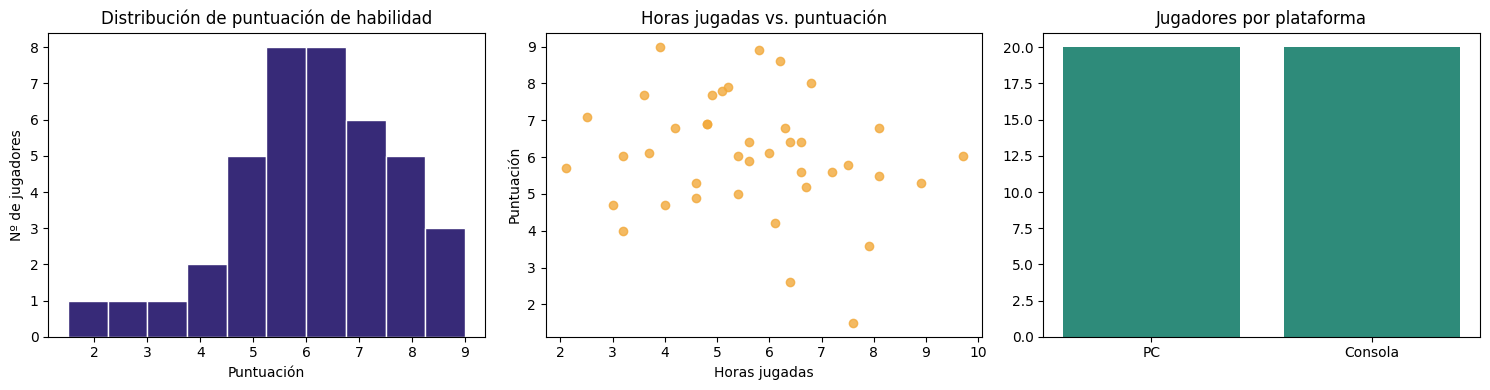

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_limpio["puntuacion"], bins=10, color="#372A78", edgecolor="white")
axes[0].set_title("Distribución de puntuación de habilidad")
axes[0].set_xlabel("Puntuación")
axes[0].set_ylabel("Nº de jugadores")

axes[1].scatter(df_limpio["horas_jugadas"], df_limpio["puntuacion"], color="#F2A93B", alpha=0.8)
axes[1].set_title("Horas jugadas vs. puntuación")
axes[1].set_xlabel("Horas jugadas")
axes[1].set_ylabel("Puntuación")

conteo = df_limpio["plataforma"].value_counts()
axes[2].bar(conteo.index, conteo.values, color="#2E8B7A")
axes[2].set_title("Jugadores por plataforma")

plt.tight_layout()
plt.show()


## 5 · Reto integrador

Encadena tú solo/a los tres pasos: carga (ya la tenemos en `df`), limpieza y una gráfica que responda a una pregunta concreta. Completa las líneas marcadas con `# TODO`.

Puntuación media en Consola: 6.01


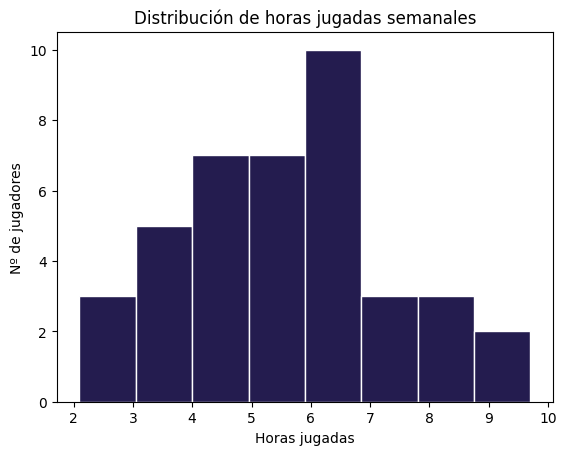

In [20]:
# TODO: ¿cuál es la puntuación media en Consola, una vez limpiado el dataset?
puntuacion_media_consola = df_codificado[df_codificado["plataforma_Consola"] == True]["puntuacion"].mean()
print(f"Puntuación media en Consola: {round(puntuacion_media_consola, 2)}")

# TODO: dibuja un histograma solo de las horas jugadas
plt.hist(df_limpio["horas_jugadas"], bins=8, color="#241C4F", edgecolor="white")
plt.title("Distribución de horas jugadas semanales")
plt.xlabel("Horas jugadas")
plt.ylabel("Nº de jugadores")
plt.show()


## 6 · Primer vistazo a Scikit-learn

Todavía no hemos visto la teoría (eso llega en UT3), pero sí podemos ver el patrón de código que vas a repetir con casi cualquier modelo: `fit()` para entrenar, `predict()` para predecir.

### Separar en entrenamiento y prueba

Antes de entrenar, reservamos una parte de los datos ("test") que el modelo no verá durante el entrenamiento — así podemos comprobar si de verdad generaliza.

In [21]:
from sklearn.model_selection import train_test_split

X = df_limpio[["horas_jugadas"]]
y = df_limpio["puntuacion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Filas de entrenamiento:", len(X_train), " · Filas de prueba:", len(X_test))


Filas de entrenamiento: 32  · Filas de prueba: 8


In [22]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X_train, y_train)                    # entrena solo con los datos de entrenamiento

horas_nuevas = pd.DataFrame({"horas_jugadas": [2, 6, 10]})
predicciones = modelo.predict(horas_nuevas)

for h, p in zip(horas_nuevas["horas_jugadas"], predicciones):
    print(f"Con {h}h jugadas, el modelo predice una puntuación de {round(p, 2)}")

print("R² sobre los datos de prueba (no vistos en el entrenamiento):", round(modelo.score(X_test, y_test), 3))


Con 2h jugadas, el modelo predice una puntuación de 6.48
Con 6h jugadas, el modelo predice una puntuación de 5.8
Con 10h jugadas, el modelo predice una puntuación de 5.12
R² sobre los datos de prueba (no vistos en el entrenamiento): -0.305


No te preocupes si `fit`/`predict` todavía no te dice mucho — es exactamente el patrón que vamos a diseccionar desde cero al empezar UT3 (Aprendizaje supervisado). Aquí solo queríamos que el código no te resultara extraño el primer día.

---
**Resumen de lo practicado:** arrays y filtrado con NumPy · carga y exploración con Pandas (`head`, `info`, `describe`) · limpieza (nulos, duplicados, `get_dummies`) · tres gráficas básicas con Matplotlib · primer `fit`/`predict` con Scikit-learn.